# Exemple simple d'un KNN à 3 dimensions 
## Auteur : Loann KAIKA

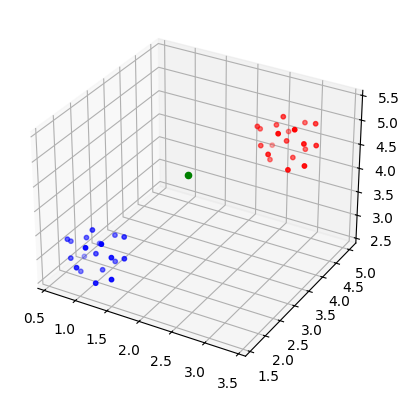

Classe prédite (k=5) = classe1
Indices des voisins: [33 10 29  4 14]
Distances des voisins: [2.53377189 2.60959767 2.64764046 2.70185122 2.73313007]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

point1 = np.array([
    [0.7, 1.8, 2.9],
    [0.8, 2.1, 3.2],
    [1.1, 2.0, 2.7],
    [1.3, 1.9, 3.1],
    [0.9, 2.3, 3.0],
    [1.2, 2.2, 2.8],
    [0.6, 2.0, 3.1],
    [1.0, 1.7, 3.3],
    [1.4, 2.1, 3.0],
    [0.8, 1.9, 2.6],
    [1.1, 2.4, 3.2],
    [0.9, 1.6, 2.9],
    [1.2, 1.8, 3.4],
    [0.7, 2.2, 2.7],
    [1.3, 2.3, 3.3],
    [1.0, 2.0, 3.0],
    [0.6, 1.9, 3.2],
    [1.4, 1.7, 2.8],
    [0.9, 2.1, 3.4],
    [1.2, 1.6, 2.7],
])

point2 = np.array([
    [2.7, 3.8, 4.9],
    [2.8, 4.1, 5.2],
    [3.1, 4.0, 4.7],
    [3.3, 3.9, 5.1],
    [2.9, 4.3, 5.0],
    [3.2, 4.2, 4.8],
    [2.6, 4.0, 5.1],
    [3.0, 3.7, 5.3],
    [3.4, 4.1, 5.0],
    [2.8, 3.9, 4.6],
    [3.1, 4.4, 5.2],
    [2.9, 3.6, 4.9],
    [3.2, 3.8, 5.4],
    [2.7, 4.2, 4.7],
    [3.3, 4.3, 5.3],
    [3.0, 4.0, 5.0],
    [2.6, 3.9, 5.2],
    [3.4, 3.7, 4.8],
    [2.9, 4.1, 5.4],
    [3.2, 3.6, 4.7],
])

test = np.array(([1,5,3],))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(point1[:,0] , point1[:,1], point1[:,2], c='blue', label="classe1", s=10)
ax.scatter(point2[:,0] , point2[:,1], point2[:,2], c='red', label="class2", s=10)
ax.scatter(test[:,0], test[:,1], test[:,2], c='green', label="test", s=20 )
plt.show()


# KNN
def knn_predict(point1, point2, test_point, k=3):
    test_point = np.asarray(test_point).reshape(-1)
    # On empile les données
    X = np.vstack([point1, point2]) # (40, 3)
    y = np.array([0]*len(point1) + [1]*len(point2)) # 0=classe1, 1=classe2

    # Distances euclidiennes à test_point
    dists = np.linalg.norm(X - test_point, axis=1)

    # Indices triés par distance croissante
    idx_sorted = np.argsort(dists)

    # k plus proches voisins
    knn_idx = idx_sorted[:k]
    knn_labels = y[knn_idx]

    # Vote majoritaire (0 ou 1)
    counts = np.bincount(knn_labels)
    pred = np.argmax(counts)

    return pred, knn_idx, dists

# Exemple d'utilisation
k = 5
pred, knn_idx, dists = knn_predict(point1, point2, test, k=k)

print(f"Classe prédite (k={k}) =", "classe1" if pred == 0 else "classe2")
print("Indices des voisins:", knn_idx)
print("Distances des voisins:", dists[knn_idx])
